# (25) deep dec — mnist

**Motivation**: host = ```yoru```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'ngd|deep')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1/8 * t_train

cfg_vae['latent_channels'] = 512
cfg_vae['latent_pixels'] = 3

# cfg_tr['batch_size'] = 100
# cfg_tr['epochs'] = 40

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

120000

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  2.8 Mil   |
|     ———     |    ———     |
|    layer    |  2.8 Mil   |
+-------------+------------+

poisson_MNIST_t-8_b-1_kms-(512,3,1)_<ngd|deep>
b200-ep400-lr(0.002)_temp(0.05)_gr(150)_(2025_07_26,10:47)

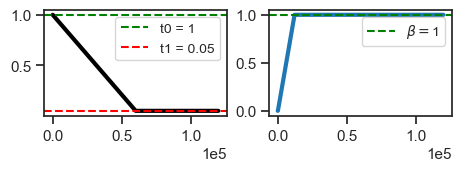

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10], device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(512, 3, 3), input_sz=(1, 28, 28), temp=1)

In [8]:
print_num_params(tr.model.layer.dec)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  Sequential |  2.8 Mil   |
|     ———     |    ———     |
|      0      |  262.7 K   |
|      1      |  1.3 Mil   |
|      2      |  598.5 K   |
|      3      |  330.1 K   |
|      4      |  149.8 K   |
|      5      |   82.6 K   |
|      6      |   37.5 K   |
|      8      |     65     |
+-------------+------------+

In [9]:
tr.model.layer.u_init[0].shape, tr.model.layer.log_bias.shape

(torch.Size([1, 512, 1, 1]), torch.Size([1, 512, 1, 1]))

In [10]:
tr.train('expand=1')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 14, avg loss: 10.067:   4%|▎       | 14/400 [47:58<22:02:52, 205.63s/it]


KeyboardInterrupt: 

100%|███████████████████████████████████| 5/5 [00:14<00:00,  2.97s/it]


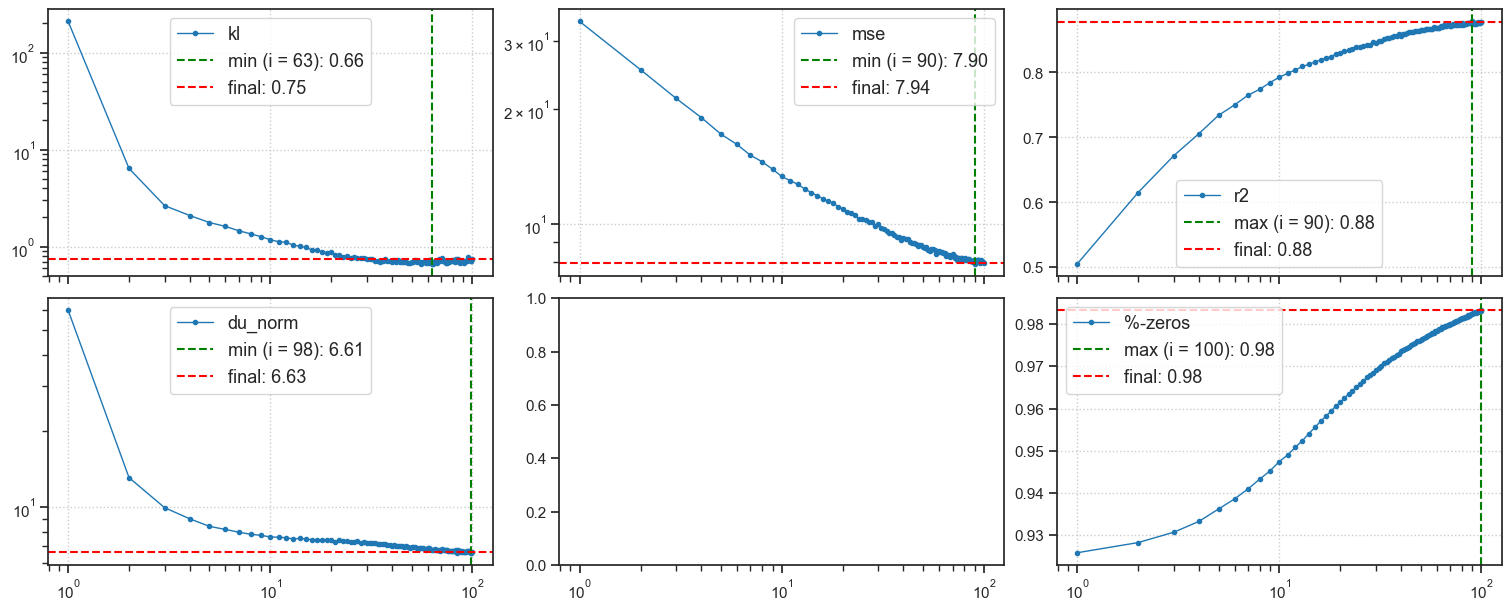

CPU times: user 17.5 s, sys: 526 ms, total: 18 s
Wall time: 18 s


In [12]:
%%time

kws = dict(
    t_total=100,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

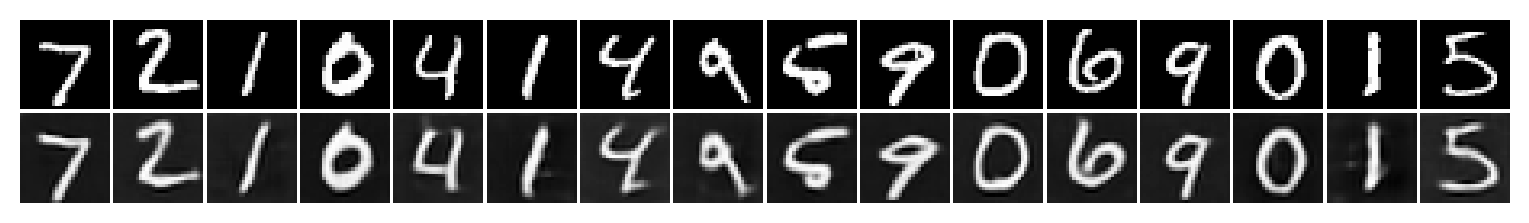

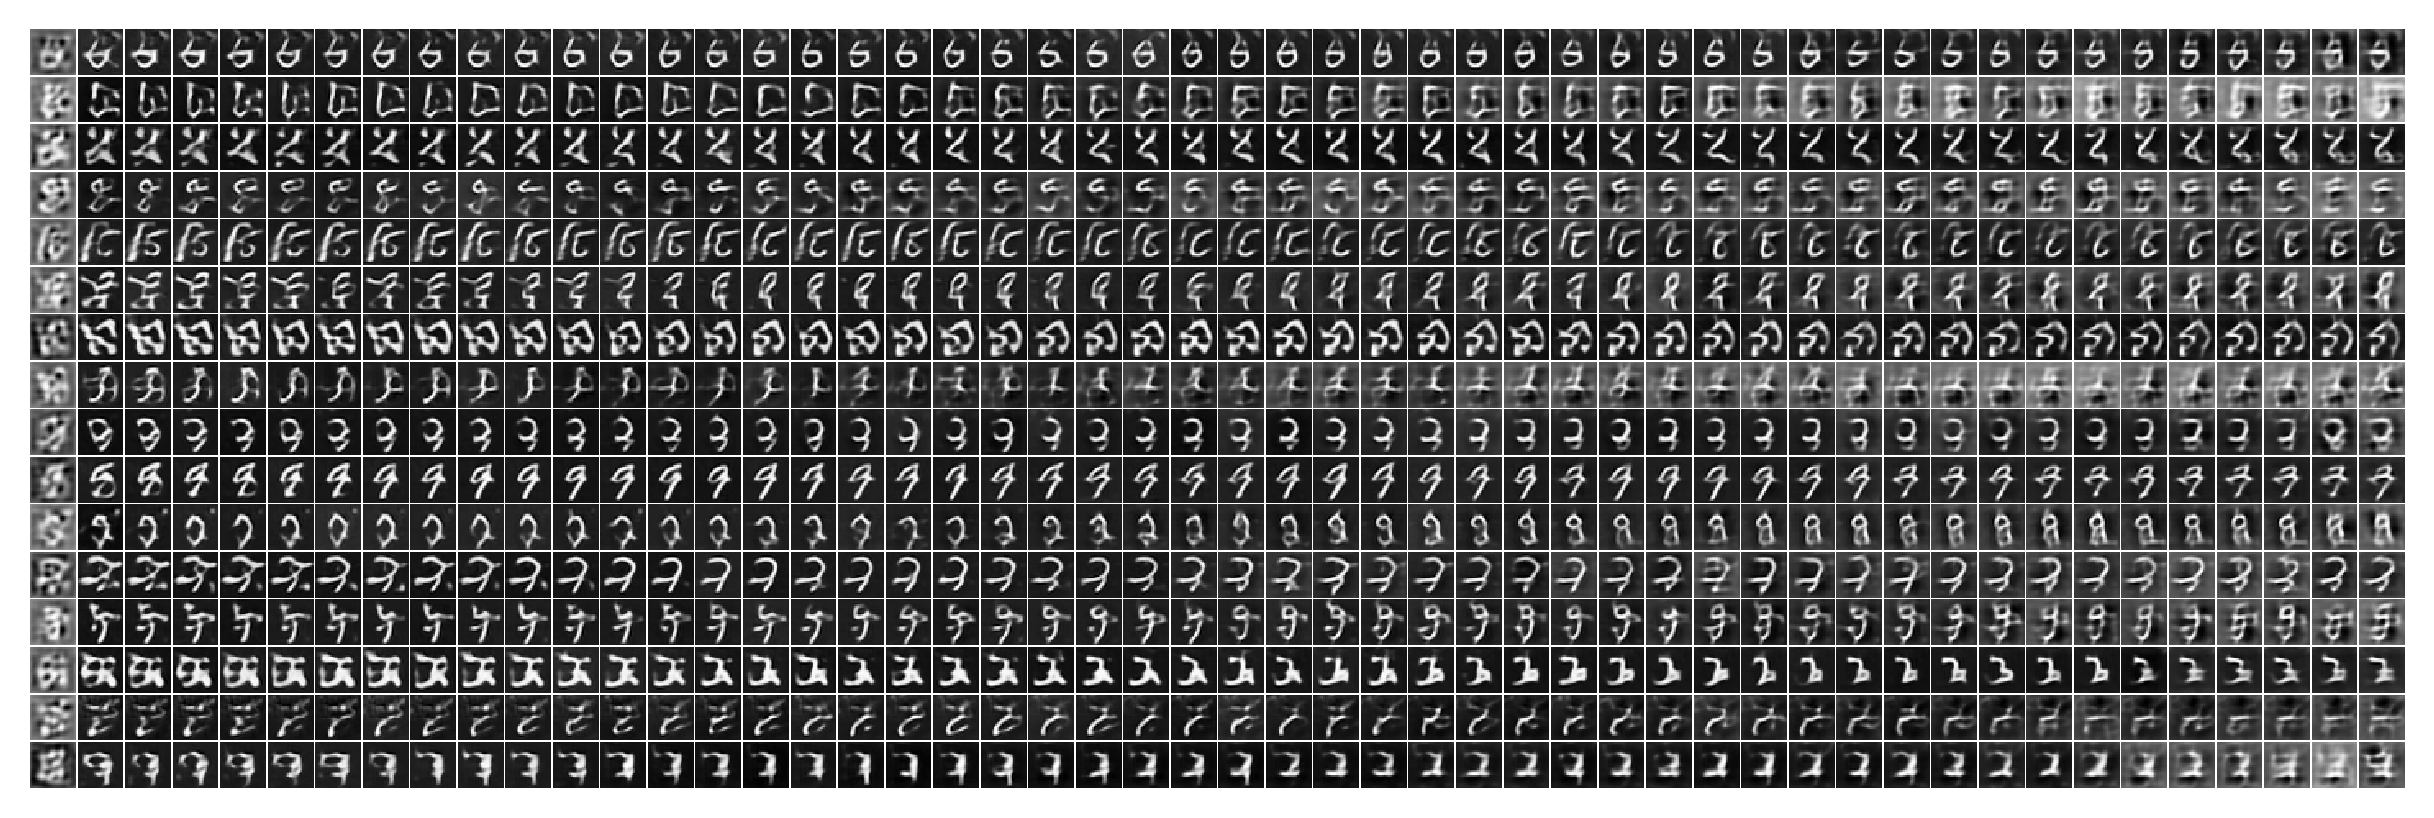

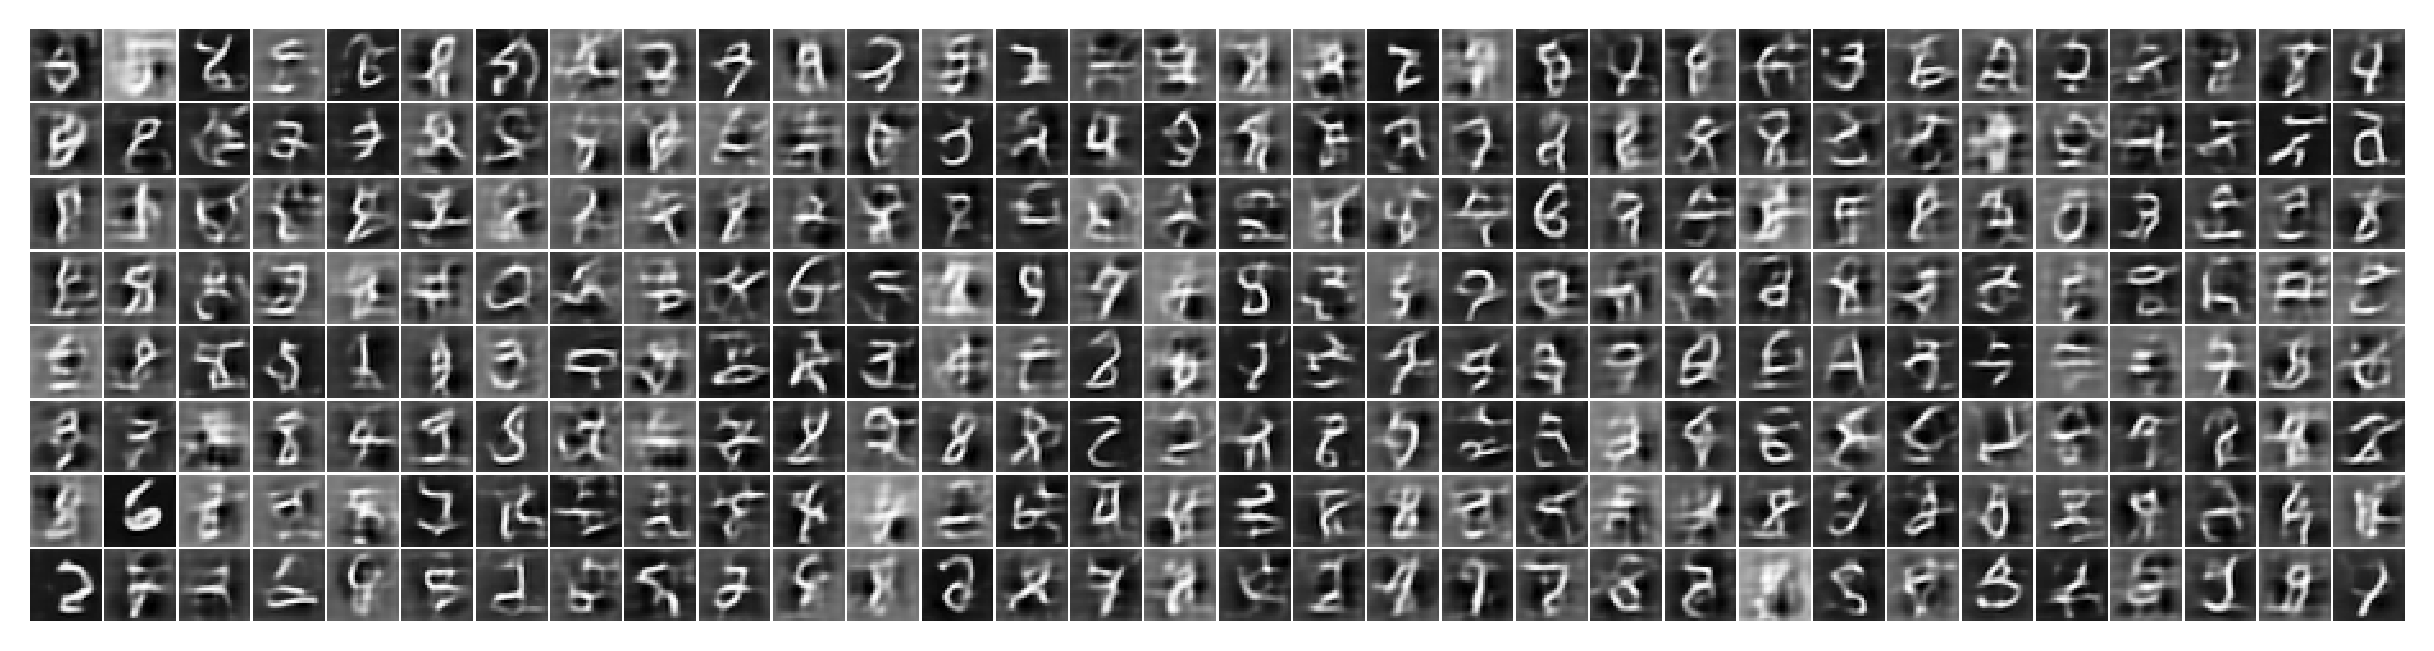

In [13]:
tr.show_recon();
tr.show_samples();

In [13]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)
bias.shape

(64,)

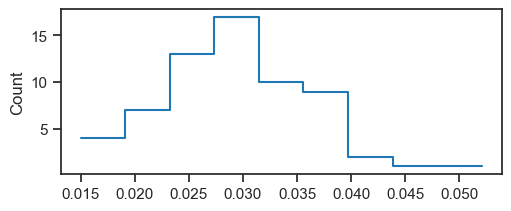

In [14]:
fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

In [15]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u0.shape

(64,)

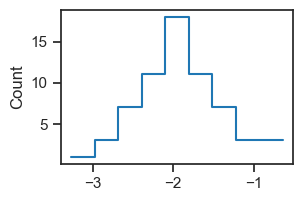

In [16]:
histplot(u0.ravel())
plt.show()

In [17]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.9772731114168571, pvalue=1.7557568759692922e-43)

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']